# Predicción de Solubilidad Molecular con GCN
**TFG — Representación Topológica (Grafos)**

## 1. Instalación de dependencias

In [ ]:
!pip install rdkit-pypi
!pip install --pre deepchem
!pip install torch pandas numpy matplotlib torch-geometric
!pip install torch-scatter torch-sparse -f https://data.pyg.org/whl/torch-$(python -c "import torch; print(torch.__version__)").html

ERROR: Could not find a version that satisfies the requirement rdkit-pypi (from versions: none)
ERROR: No matching distribution found for rdkit-pypi
Looking in links: https://data.pyg.org/whl/torch-2.10.0+cpu.html


## 2. Importaciones

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import deepchem as dc
from itertools import product

from torch_geometric.data import Data, DataLoader
from torch_geometric.nn import GCNConv, global_mean_pool

from rdkit import Chem
from rdkit.Chem import rdchem

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch version: {torch.__version__}')
print(f'Dispositivo: {device}')

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING W&B installed but not logged in.  Run `wandb login` or set the WANDB_API_KEY env variable.
Instructions for updating:
experimental_relax_shapes is deprecated, use reduce_retracing instead
wandb: WARNING W&B installed but not logged in.  Run `wandb login` or set the WANDB_API_KEY env variable.


PyTorch version: 2.10.0+cpu
Dispositivo: cpu


## 3. Carga del dataset ESOL con Scaffold Split

In [ ]:
tasks, datasets, transformers = dc.molnet.load_delaney(
    featurizer='Raw',
    splitter='scaffold'
)

train_dataset, val_dataset, test_dataset = datasets

train_smiles = train_dataset.ids.tolist()
val_smiles   = val_dataset.ids.tolist()
test_smiles  = test_dataset.ids.tolist()

train_labels = train_dataset.y.flatten().tolist()
val_labels   = val_dataset.y.flatten().tolist()
test_labels  = test_dataset.y.flatten().tolist()

print(f'Train: {len(train_smiles)} | Val: {len(val_smiles)} | Test: {len(test_smiles)}')

Train: 902 | Val: 113 | Test: 113


## 4. Normalización de LogS

In [ ]:
mean_logs = np.mean(train_labels)
std_logs  = np.std(train_labels)

train_labels_norm = [(y - mean_logs) / std_logs for y in train_labels]
val_labels_norm   = [(y - mean_logs) / std_logs for y in val_labels]
test_labels_norm  = [(y - mean_logs) / std_logs for y in test_labels]

print(f'Media LogS (train): {mean_logs:.4f}')
print(f'Std LogS  (train):  {std_logs:.4f}')

Media LogS (train): -0.0000
Std LogS  (train):  1.0000


## 5. Conversión de SMILES a grafos

Cada molécula se convierte en un grafo usando RDKit:
- **Nodos**: características atómicas (tipo de átomo, hibridación, carga formal, hidrógenos, anillo, aromaticidad)
- **Aristas**: características del enlace (tipo de enlace, pertenece a anillo)

In [ ]:
# Mapas de codificación
ATOM_TYPE = {
    'C': 0, 'N': 1, 'O': 2, 'F': 3, 'P': 4,
    'S': 5, 'Cl': 6, 'Br': 7, 'I': 8, 'other': 9
}

HYBRIDIZATION = {
    rdchem.HybridizationType.SP:    0,
    rdchem.HybridizationType.SP2:   1,
    rdchem.HybridizationType.SP3:   2,
    rdchem.HybridizationType.SP3D:  3,
    rdchem.HybridizationType.SP3D2: 4,
    rdchem.HybridizationType.OTHER: 5
}

BOND_TYPE = {
    rdchem.BondType.SINGLE:   0,
    rdchem.BondType.DOUBLE:   1,
    rdchem.BondType.TRIPLE:   2,
    rdchem.BondType.AROMATIC: 3
}

def get_atom_features(atom):
    """
    Vector de características de un átomo (20 valores):
    - Tipo de átomo: one-hot (10)
    - Hibridación: one-hot (6)
    - Carga formal (1)
    - Nº hidrógenos implícitos (1)
    - ¿En anillo? (1)
    - ¿Aromático? (1)
    """
    atom_type = [0] * len(ATOM_TYPE)
    idx = ATOM_TYPE.get(atom.GetSymbol(), ATOM_TYPE['other'])
    atom_type[idx] = 1

    hyb = [0] * len(HYBRIDIZATION)
    hyb_idx = HYBRIDIZATION.get(atom.GetHybridization(), 5)
    hyb[hyb_idx] = 1

    charge      = [atom.GetFormalCharge()]
    num_hs      = [atom.GetTotalNumHs()]
    in_ring     = [int(atom.IsInRing())]
    is_aromatic = [int(atom.GetIsAromatic())]

    return atom_type + hyb + charge + num_hs + in_ring + is_aromatic

def get_bond_features(bond):
    """
    Vector de características de un enlace (5 valores):
    - Tipo de enlace: one-hot (4)
    - ¿En anillo? (1)
    """
    bond_type = [0] * len(BOND_TYPE)
    bt_idx = BOND_TYPE.get(bond.GetBondType(), 0)
    bond_type[bt_idx] = 1
    in_ring = [int(bond.IsInRing())]
    return bond_type + in_ring

def smiles_to_graph(smiles, label):
    """Convierte una cadena SMILES en un objeto Data de PyTorch Geometric."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    # Características de nodos
    node_features = [get_atom_features(atom) for atom in mol.GetAtoms()]
    x = torch.tensor(node_features, dtype=torch.float)

    # Índices y características de aristas
    edge_index = []
    edge_attr  = []
    for bond in mol.GetBonds():
        i  = bond.GetBeginAtomIdx()
        j  = bond.GetEndAtomIdx()
        bf = get_bond_features(bond)
        # Añadir en ambas direcciones (grafo no dirigido)
        edge_index += [[i, j], [j, i]]
        edge_attr  += [bf, bf]

    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    edge_attr  = torch.tensor(edge_attr,  dtype=torch.float)
    y          = torch.tensor([label],    dtype=torch.float)

    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)

# Verificar características
mol_test = Chem.MolFromSmiles('CCO')
print(f'Características por nodo:   {len(get_atom_features(mol_test.GetAtomWithIdx(0)))}')
print(f'Características por arista: {len(get_bond_features(mol_test.GetBondWithIdx(0)))}')

Características por nodo:   20
Características por arista: 5


## 6. Construcción de los datasets de grafos

In [ ]:
def build_dataset(smiles_list, labels_norm):
    graphs = []
    for smi, label in zip(smiles_list, labels_norm):
        g = smiles_to_graph(smi, label)
        if g is not None:
            graphs.append(g)
    return graphs

train_graphs = build_dataset(train_smiles, train_labels_norm)
val_graphs   = build_dataset(val_smiles,   val_labels_norm)
test_graphs  = build_dataset(test_smiles,  test_labels_norm)

print(f'Grafos train: {len(train_graphs)}')
print(f'Grafos val:   {len(val_graphs)}')
print(f'Grafos test:  {len(test_graphs)}')

# Ejemplo de grafo
g = train_graphs[0]
print(f'\nEjemplo:')
print(f'  Nodos:   {g.x.shape}')
print(f'  Aristas: {g.edge_index.shape}')
print(f'  Label:   {g.y.item():.4f}')

Grafos train: 902
Grafos val:   113
Grafos test:  113

Ejemplo:
  Nodos:   torch.Size([11, 20])
  Aristas: torch.Size([2, 20])
  Label:   0.3904


## 7. DataLoaders

In [ ]:
BATCH_SIZE = 32

train_loader = DataLoader(train_graphs, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_graphs,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_graphs,  batch_size=BATCH_SIZE)

print(f'Batches en train: {len(train_loader)}')

Batches en train: 29


/tmp/ipykernel_7918/3314987887.py:3: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  train_loader = DataLoader(train_graphs, batch_size=BATCH_SIZE, shuffle=True)
/tmp/ipykernel_7918/3314987887.py:4: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  val_loader   = DataLoader(val_graphs,   batch_size=BATCH_SIZE)
/tmp/ipykernel_7918/3314987887.py:5: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  test_loader  = DataLoader(test_graphs,  batch_size=BATCH_SIZE)


## 8. Arquitectura del modelo GCN

El modelo consta de:
- **Capas GCN**: message passing entre nodos vecinos
- **Global Mean Pooling**: agrega todos los nodos en un vector molecular
- **Capas densas**: hidden → 64 → 1 para la predicción final

In [ ]:
class GCNModel(nn.Module):
    def __init__(self, node_features, hidden_size=128, num_layers=2, dropout=0.2):
        super(GCNModel, self).__init__()

        # Capas GCN
        self.convs = nn.ModuleList()
        self.convs.append(GCNConv(node_features, hidden_size))
        for _ in range(num_layers - 1):
            self.convs.append(GCNConv(hidden_size, hidden_size))

        self.dropout = nn.Dropout(dropout)
        self.relu    = nn.ReLU()

        # Capas densas de predicción
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, data):
        x          = data.x
        edge_index = data.edge_index
        batch      = data.batch

        # Propagación por capas GCN
        for conv in self.convs:
            x = conv(x, edge_index)
            x = self.relu(x)
            x = self.dropout(x)

        # Global mean pooling
        x = global_mean_pool(x, batch)

        # Predicción final
        out = self.fc(x)
        return out.squeeze(1)


NODE_FEATURES = train_graphs[0].x.shape[1]
model_test    = GCNModel(node_features=NODE_FEATURES).to(device)
print(model_test)
total_test = sum(p.numel() for p in model_test.parameters() if p.requires_grad)
print(f'\nParámetros entrenables: {total_test:,}')

GCNModel(
  (convs): ModuleList(
    (0): GCNConv(20, 128)
    (1): GCNConv(128, 128)
  )
  (dropout): Dropout(p=0.2, inplace=False)
  (relu): ReLU()
  (fc): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
  )
)

Parámetros entrenables: 27,521


## 9. Funciones de entrenamiento y evaluación

In [ ]:
def train_epoch_gcn(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for data in loader:
        data = data.to(device)
        optimizer.zero_grad()
        pred = model(data)
        loss = criterion(pred, data.y.squeeze())
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * data.num_graphs
    return total_loss / len(loader.dataset)


def evaluate_gcn(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            pred = model(data)
            loss = criterion(pred, data.y.squeeze())
            total_loss += loss.item() * data.num_graphs
    return np.sqrt(total_loss / len(loader.dataset))

print('Funciones definidas correctamente.')

Funciones definidas correctamente.


## 10. Grid Search de hiperparámetros

In [ ]:
# param_grid = {
#     'hidden_size': [64, 128, 256],
#     'num_layers':  [1, 2, 3],
#     'dropout':     [0.1, 0.2, 0.3]
# }

# combinations = list(product(
#     param_grid['hidden_size'],
#     param_grid['num_layers'],
#     param_grid['dropout']
# ))

# print(f'Total combinaciones: {len(combinations)}')
# results = []

# for hidden_size, num_layers, dropout in combinations:

#     model_gs     = GCNModel(
#         node_features=NODE_FEATURES,
#         hidden_size=hidden_size,
#         num_layers=num_layers,
#         dropout=dropout
#     ).to(device)
#     optimizer_gs = torch.optim.Adam(model_gs.parameters(), lr=0.001)
#     criterion_gs = nn.MSELoss()

#     best_val         = float('inf')
#     patience_counter = 0

#     for epoch in range(50):
#         train_epoch_gcn(model_gs, train_loader, optimizer_gs, criterion_gs, device)
#         val_rmse = evaluate_gcn(model_gs, val_loader, criterion_gs, device)

#         if val_rmse < best_val:
#             best_val         = val_rmse
#             patience_counter = 0
#         else:
#             patience_counter += 1

#         if patience_counter >= 10:
#             break

#     results.append({
#         'hidden_size': hidden_size,
#         'num_layers':  num_layers,
#         'dropout':     dropout,
#         'val_rmse':    best_val
#     })

#     print(f'hidden={hidden_size:3d} | layers={num_layers} | '
#           f'dropout={dropout} | Val RMSE: {best_val:.4f}')

# results_df = pd.DataFrame(results).sort_values('val_rmse').reset_index(drop=True)
# print('\n--- Top 5 combinaciones ---')
# print(results_df.head())

# best_params  = results_df.iloc[0]
# BEST_HIDDEN  = int(best_params.hidden_size)
# BEST_LAYERS  = int(best_params.num_layers)
# BEST_DROPOUT = best_params.dropout

# print(f'\nMejor configuración:')
# print(f'  hidden_size: {BEST_HIDDEN}')
# print(f'  num_layers:  {BEST_LAYERS}')
# print(f'  dropout:     {BEST_DROPOUT}')
# print(f'  Val RMSE:    {best_params.val_rmse:.4f}')

## 11. Entrenamiento final con los mejores hiperparámetros

Scaffold Split result

In [ ]:
BEST_HIDDEN=256
BEST_LAYERS=3
BEST_DROPOUT=0.2

In [ ]:
EPOCHS   = 100
LR       = 0.001
PATIENCE = 10

model = GCNModel(
    node_features=NODE_FEATURES,
    hidden_size=BEST_HIDDEN,
    num_layers=BEST_LAYERS,
    dropout=BEST_DROPOUT
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.MSELoss()

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Parámetros entrenables: {total_params:,}')

best_val_rmse    = float('inf')
best_state       = None
patience_counter = 0
history          = {'train_rmse': [], 'val_rmse': []}

for epoch in range(1, EPOCHS + 1):
    train_loss = train_epoch_gcn(model, train_loader, optimizer, criterion, device)
    val_rmse   = evaluate_gcn(model, val_loader, criterion, device)
    train_rmse = np.sqrt(train_loss)

    history['train_rmse'].append(train_rmse)
    history['val_rmse'].append(val_rmse)

    if val_rmse < best_val_rmse:
        best_val_rmse    = val_rmse
        best_state       = model.state_dict()
        patience_counter = 0
    else:
        patience_counter += 1

    if epoch % 10 == 0:
        print(f'Época {epoch:3d} | Train RMSE: {train_rmse:.4f} | Val RMSE: {val_rmse:.4f}')

    if patience_counter >= PATIENCE:
        print(f'\nEarly stopping en época {epoch}')
        break

print(f'\nMejor Val RMSE (normalizado): {best_val_rmse:.4f}')

Parámetros entrenables: 153,473
Época  10 | Train RMSE: 0.5701 | Val RMSE: 0.6384
Época  20 | Train RMSE: 0.4919 | Val RMSE: 0.6780
Época  30 | Train RMSE: 0.4603 | Val RMSE: 0.6743
Época  40 | Train RMSE: 0.3936 | Val RMSE: 0.6768

Early stopping en época 47

Mejor Val RMSE (normalizado): 0.5872


## 12. Evaluación final en test

In [ ]:
model.load_state_dict(best_state)
test_rmse_norm = evaluate_gcn(model, test_loader, criterion, device)
test_rmse      = test_rmse_norm * std_logs

print(f'RMSE en test (normalizado): {test_rmse_norm:.4f}')
print(f'RMSE en test (log mol/L):   {test_rmse:.4f}')

RMSE en test (normalizado): 0.6686
RMSE en test (log mol/L):   0.6686


## 13. Curva de aprendizaje

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(history['train_rmse'], label='Train RMSE')
plt.plot(history['val_rmse'],   label='Val RMSE')
plt.xlabel('Época')
plt.ylabel('RMSE (normalizado)')
plt.title('Curva de aprendizaje — GCN')
plt.legend()
plt.tight_layout()
plt.savefig('gcn_scaffold_learning_curve.png', dpi=150)
plt.show()

## 14. Diagnóstico — Predicciones vs valores reales

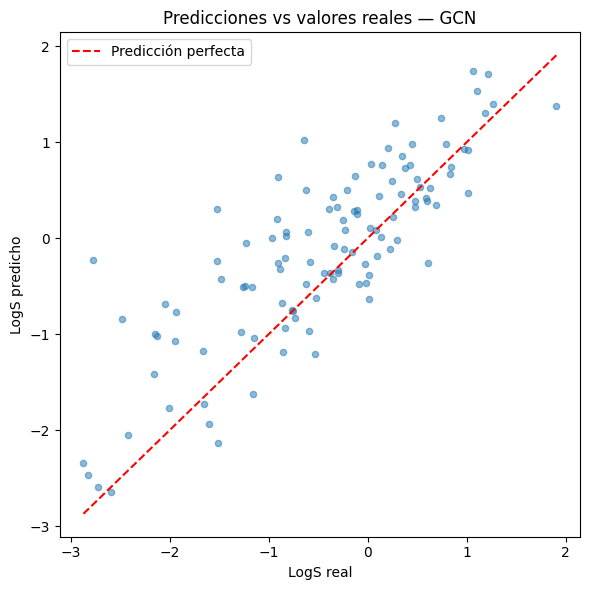

Media predicciones:   -0.130
Std predicciones:     0.927
Media valores reales: -0.450
Std valores reales:   1.026


In [ ]:
model.eval()
preds = []
trues = []

with torch.no_grad():
    for data in test_loader:
        data = data.to(device)
        pred = model(data).cpu().numpy()
        preds.extend(pred)
        trues.extend(data.y.cpu().numpy())

preds = np.array(preds) * std_logs + mean_logs
trues = np.array(trues) * std_logs + mean_logs

plt.figure(figsize=(6, 6))
plt.scatter(trues, preds, alpha=0.5, s=20)
plt.plot([min(trues), max(trues)], [min(trues), max(trues)],
         'r--', label='Predicción perfecta')
plt.xlabel('LogS real')
plt.ylabel('LogS predicho')
plt.title('Predicciones vs valores reales — GCN')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Media predicciones:   {preds.mean():.3f}')
print(f'Std predicciones:     {preds.std():.3f}')
print(f'Media valores reales: {trues.mean():.3f}')
print(f'Std valores reales:   {trues.std():.3f}')

## 15. Resumen de resultados

In [ ]:
print('=' * 50)
print('RESUMEN — MODELO GCN')
print('=' * 50)
print(f'Características por nodo: {NODE_FEATURES}')
print(f'Hidden size:    {BEST_HIDDEN}')
print(f'Num layers:     {BEST_LAYERS}')
print(f'Dropout:        {BEST_DROPOUT}')
print(f'Optimizador:    Adam (lr={LR})')
print(f'Parámetros:     {total_params:,}')
print(f'Val RMSE:       {best_val_rmse * std_logs:.4f} log mol/L')
print(f'Test RMSE:      {test_rmse:.4f} log mol/L')
print('=' * 50)

RESUMEN — MODELO GCN
Características por nodo: 20
Hidden size:    256
Num layers:     3
Dropout:        0.2
Optimizador:    Adam (lr=0.001)
Parámetros:     153,473
Val RMSE:       0.5872 log mol/L
Test RMSE:      0.6686 log mol/L


## 16. Análisis de interpretabilidad con GNNExplainer

GNNExplainer identifica qué átomos y enlaces contribuyen más a la predicción del modelo GCN, sin modificar su arquitectura ni sus pesos.

In [ ]:
from torch_geometric.explain import Explainer, GNNExplainer
from rdkit.Chem.Draw import rdMolDraw2D
import matplotlib.cm as cm
from PIL import Image as PILImage
import io

# Wrapper necesario para que GNNExplainer funcione con nuestro modelo
class GCNWrapper(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x, edge_index, batch=None):
        from torch_geometric.data import Data
        if batch is None:
            batch = torch.zeros(x.size(0), dtype=torch.long, device=x.device)
        data = Data(x=x, edge_index=edge_index, batch=batch)
        return self.model(data).unsqueeze(-1)

wrapped_model = GCNWrapper(model).to(device)

explainer = Explainer(
    model=wrapped_model,
    algorithm=GNNExplainer(epochs=200),
    explanation_type='model',
    node_mask_type='attributes',
    edge_mask_type='object',
    model_config=dict(
        mode='regression',
        task_level='graph',
        return_type='raw'
    )
)

print('GNNExplainer configurado correctamente.')


GNNExplainer configurado correctamente.


In [ ]:
def explain_molecule(smiles, logS_real, model, explainer, device,
                     mean_logs, std_logs, title=''):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        print(f'SMILES invalido: {smiles}')
        return

    graph = smiles_to_graph(smiles, 0.0).to(device)
    graph.batch = torch.zeros(graph.x.size(0), dtype=torch.long, device=device)

    model.eval()
    with torch.no_grad():
        pred_norm = model(graph).item()
    pred_logS = pred_norm * std_logs + mean_logs

    explanation = explainer(
        x=graph.x,
        edge_index=graph.edge_index,
        batch=graph.batch
    )

    # Importancia de nodos
    node_mask = explanation.node_mask
    node_imp  = node_mask.mean(dim=1).cpu().detach().numpy()
    if node_imp.max() > 0:
        node_imp = node_imp / node_imp.max()

    # Importancia de aristas
    edge_mask     = explanation.edge_mask.cpu().detach().numpy()
    if edge_mask.max() > 0:
        edge_mask = edge_mask / edge_mask.max()

    edge_index_np = graph.edge_index.cpu().numpy()
    bond_imp = np.zeros(mol.GetNumBonds())
    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        mask_ij = ((edge_index_np[0] == i) & (edge_index_np[1] == j))
        mask_ji = ((edge_index_np[0] == j) & (edge_index_np[1] == i))
        vals = []
        if mask_ij.any(): vals.append(edge_mask[mask_ij][0])
        if mask_ji.any(): vals.append(edge_mask[mask_ji][0])
        bond_imp[bond.GetIdx()] = np.mean(vals) if vals else 0.0

    # Colorear la molecula
    cmap = cm.get_cmap('RdYlGn_r')
    atom_colors = {i: cmap(node_imp[i])[:3] for i in range(mol.GetNumAtoms())}
    bond_colors = {b: cmap(bond_imp[b])[:3] for b in range(mol.GetNumBonds())}

    drawer = rdMolDraw2D.MolDraw2DCairo(600, 450)
    rdMolDraw2D.PrepareMolForDrawing(mol)
    drawer.DrawMolecule(
        mol,
        highlightAtoms=list(range(mol.GetNumAtoms())),
        highlightAtomColors=atom_colors,
        highlightBonds=list(range(mol.GetNumBonds())),
        highlightBondColors=bond_colors
    )
    drawer.FinishDrawing()
    png = drawer.GetDrawingText()

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    img = PILImage.open(io.BytesIO(png))
    ax1.imshow(img)
    ax1.axis('off')
    ax1.set_title(
        f'LogS real: {logS_real:.2f} | LogS predicho: {pred_logS:.2f}\n'
        'Rojo = alta importancia | Verde = baja importancia',
        fontsize=10
    )

    atom_symbols = [mol.GetAtomWithIdx(i).GetSymbol() for i in range(mol.GetNumAtoms())]
    bar_colors   = [cmap(node_imp[i])[:3] for i in range(mol.GetNumAtoms())]
    ax2.bar(range(mol.GetNumAtoms()), node_imp, color=bar_colors,
            edgecolor='black', linewidth=0.5)
    ax2.set_xticks(range(mol.GetNumAtoms()))
    ax2.set_xticklabels(
        [f'{s}\n{i}' for i, s in enumerate(atom_symbols)], fontsize=8
    )
    ax2.set_xlabel('Atomo (simbolo e indice)')
    ax2.set_ylabel('Importancia normalizada')
    ax2.set_title('Importancia de cada atomo (GNNExplainer)')
    ax2.set_ylim(0, 1.1)

    if title:
        fig.suptitle(title, fontsize=12, fontweight='bold')

    plt.tight_layout()
    safe_name = ''.join(c for c in smiles[:15] if c.isalnum())
    plt.savefig(f'explain_{safe_name}.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f'LogS real:     {logS_real:.2f} log mol/L')
    print(f'LogS predicho: {pred_logS:.2f} log mol/L')
    print('\nTop 5 atomos mas importantes:')
    for idx in np.argsort(node_imp)[::-1][:5]:
        sym = mol.GetAtomWithIdx(int(idx)).GetSymbol()
        print(f'  Atomo {idx:2d} ({sym}): importancia = {node_imp[idx]:.3f}')

print('Funcion explain_molecule definida.')


Funcion explain_molecule definida.


In [ ]:
# Seleccionar moleculas representativas del conjunto de test
test_df = pd.DataFrame({
    'smiles': test_smiles,
    'logS':   test_labels
}).sort_values('logS').reset_index(drop=True)

print('Molecula mas insoluble:')
print(test_df.iloc[0])
print('\nMolecula mas soluble:')
print(test_df.iloc[-1])
print('\nMolecula intermedia:')
print(test_df.iloc[len(test_df)//2])


Molecula mas insoluble:
smiles    c1cc2cccc3c4cccc5cccc(c(c1)c23)c54
logS                               -2.872722
Name: 0, dtype: object

Molecula mas soluble:
smiles    O=C1CCCN1
logS       1.904887
Name: 112, dtype: object

Molecula intermedia:
smiles    N(c1ccccc1)c2ccccc2
logS                -0.308277
Name: 56, dtype: object


/tmp/ipykernel_7918/3243531445.py:46: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('RdYlGn_r')


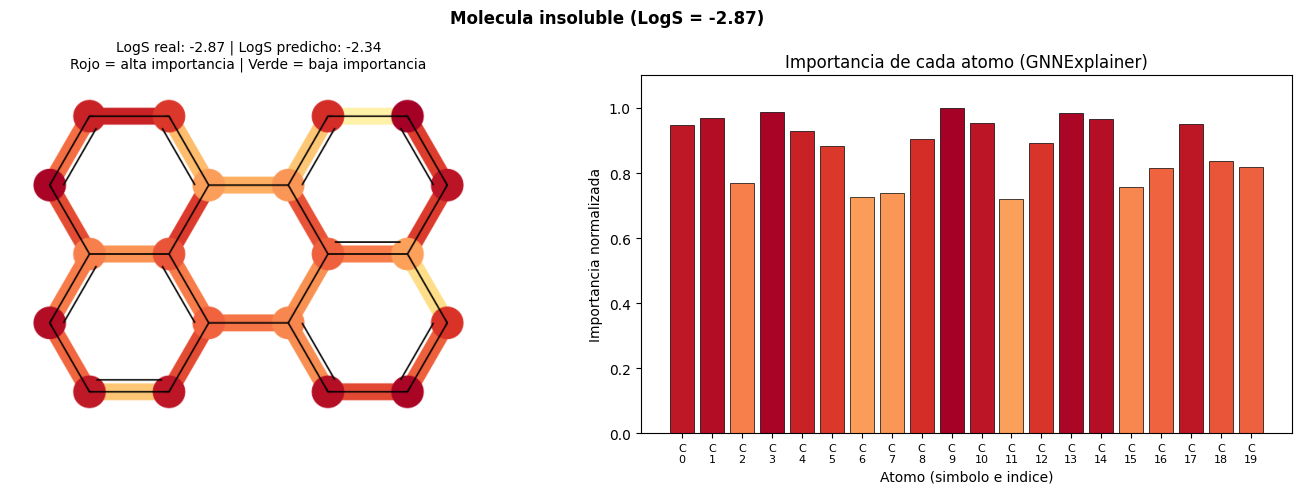

LogS real:     -2.87 log mol/L
LogS predicho: -2.34 log mol/L

Top 5 atomos mas importantes:
  Atomo  9 (C): importancia = 1.000
  Atomo  3 (C): importancia = 0.989
  Atomo 13 (C): importancia = 0.985
  Atomo  1 (C): importancia = 0.970
  Atomo 14 (C): importancia = 0.965


In [ ]:
# Molecula MUY INSOLUBLE
row = test_df.iloc[0]
explain_molecule(
    smiles=row['smiles'],
    logS_real=row['logS'],
    model=model,
    explainer=explainer,
    device=device,
    mean_logs=mean_logs,
    std_logs=std_logs,
    title='Molecula insoluble (LogS = ' + str(round(row['logS'], 2)) + ')'
)


/tmp/ipykernel_7918/3243531445.py:46: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('RdYlGn_r')


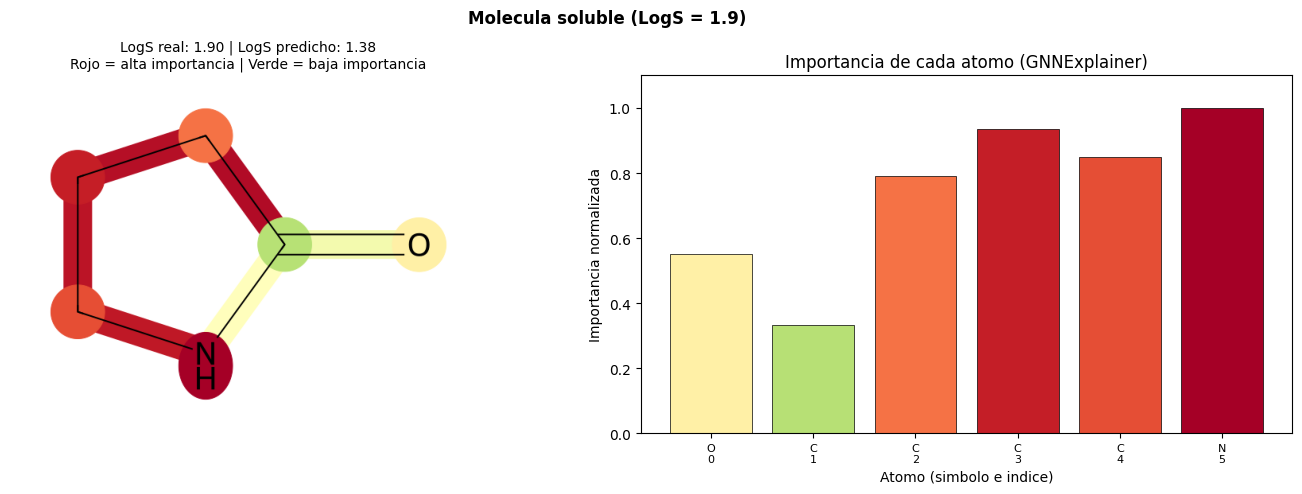

LogS real:     1.90 log mol/L
LogS predicho: 1.38 log mol/L

Top 5 atomos mas importantes:
  Atomo  5 (N): importancia = 1.000
  Atomo  3 (C): importancia = 0.935
  Atomo  4 (C): importancia = 0.849
  Atomo  2 (C): importancia = 0.791
  Atomo  0 (O): importancia = 0.550


In [ ]:
# Molecula MUY SOLUBLE
row = test_df.iloc[-1]
explain_molecule(
    smiles=row['smiles'],
    logS_real=row['logS'],
    model=model,
    explainer=explainer,
    device=device,
    mean_logs=mean_logs,
    std_logs=std_logs,
    title='Molecula soluble (LogS = ' + str(round(row['logS'], 2)) + ')'
)


/tmp/ipykernel_7918/3243531445.py:46: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('RdYlGn_r')


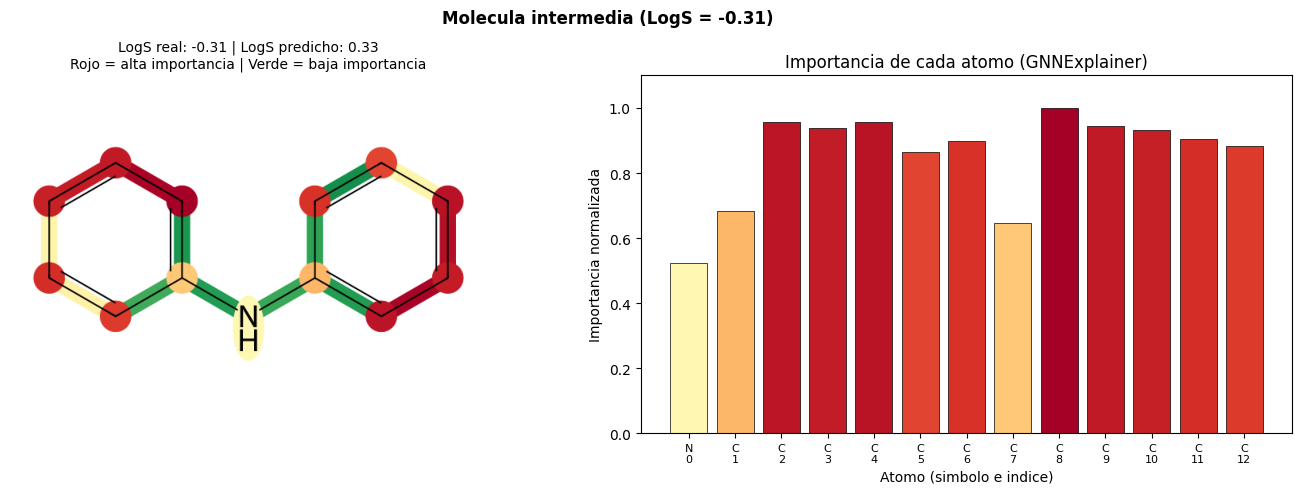

LogS real:     -0.31 log mol/L
LogS predicho: 0.33 log mol/L

Top 5 atomos mas importantes:
  Atomo  8 (C): importancia = 1.000
  Atomo  4 (C): importancia = 0.958
  Atomo  2 (C): importancia = 0.956
  Atomo  9 (C): importancia = 0.944
  Atomo  3 (C): importancia = 0.938


In [ ]:
# Molecula INTERMEDIA
row = test_df.iloc[len(test_df)//2]
explain_molecule(
    smiles=row['smiles'],
    logS_real=row['logS'],
    model=model,
    explainer=explainer,
    device=device,
    mean_logs=mean_logs,
    std_logs=std_logs,
    title='Molecula intermedia (LogS = ' + str(round(row['logS'], 2)) + ')'
)


In [ ]:
# Guardar el modelo entrenado
torch.save({
    'model_state_dict': model.state_dict(),
    'BEST_HIDDEN':      BEST_HIDDEN,
    'BEST_LAYERS':      BEST_LAYERS,
    'BEST_DROPOUT':     BEST_DROPOUT,
    'mean_logs':        mean_logs,
    'std_logs':         std_logs,
    'NODE_FEATURES':    NODE_FEATURES
}, 'gcn_scaffold_split.pth')

print('Modelo guardado como gcn_scaffold_split.pth')